# FashionMNIST 分类 —— 使用 PyTorch 全连接神经网络（Pytorch分类与回归.md）

本脚本实现了 FashionMNIST 数据集的 10 分类任务，包括：
1. 数据加载与预处理
2. 数据可视化
3. 三层全连接神经网络构建
4. 模型训练与验证
5. 模型参数统计

In [1]:
import torch  # PyTorch 核心库，提供张量运算与自动求导
import torch.nn as nn  # 神经网络模块，提供 Linear、ReLU 等层
import torch.optim as optim  # 优化器模块，提供 SGD、Adam 等
from torchvision import datasets, transforms  # 提供常用数据集与数据预处理变换
import matplotlib.pyplot as plt  # 绘图库，用于数据可视化与训练曲线绘制
from matplotlib import rcParams  # matplotlib 配置字典，用于设置全局绘图参数
import os  # 操作系统接口，用于创建目录、判断文件是否存在等
from torch.utils.tensorboard import SummaryWriter  # TensorBoard 写入器，用于记录训练日志

## 1. 数据加载与预处理

In [2]:
# 定义数据预处理流程
# transforms.Compose: 将多个 transform 操作组合在一起，按顺序执行
# transforms.ToTensor(): 将 PIL.Image (0-255) 转换为 torch.Tensor (0.0-1.0)，并将 H×W×C 变为 C×H×W
transform = transforms.Compose([
    transforms.ToTensor(),
])

In [3]:
# 下载并加载 FashionMNIST 训练集
# root: 数据存放目录
# train=True: 加载训练集（60,000 张）
# download=False: 不重新下载（若已下载过；首次使用需设为 True）
# transform: 对每张图片施加的预处理操作
full_train_dataset = datasets.FashionMNIST(
    root='./data',  # 数据集存储路径
    train=True,  # True=训练集, False=测试集
    download=True,  # 是否下载数据集（首次需设为 True）
    transform=transform  # 数据预处理变换
)

100%|██████████| 26.4M/26.4M [00:01<00:00, 13.6MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 201kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.73MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 3.80MB/s]


In [4]:
# 从训练集中分出 5000 张作为验证集
# 总训练样本 60,000 → 训练集 55,000 + 验证集 5,000
train_size = len(full_train_dataset) - 5000  # 训练集大小: 55000
val_size = 5000  # 验证集大小: 5000

In [5]:
# random_split: 将数据集随机打乱后按指定长度切分，避免验证集与训练集分布不同
# generator: 随机数生成器，用于控制切分时的打乱顺序
#   - torch.Generator(): 创建一个新的随机数生成器实例（独立于全局默认生成器，互不干扰）
#   - .manual_seed(42): 手动设置随机种子为 42，使生成的随机序列固定
#     作用: 保证每次运行脚本时，数据集的切分方式完全一致
#           → 训练集/验证集划分结果可复现，便于调试与结果对比
#     若不指定 generator，random_split 会使用全局随机状态，每次运行划分不同，结果难以复现
#   - "42" 是机器学习社区常用的种子值，任意整数均可
generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = torch.utils.data.random_split(
    full_train_dataset,  # 原始数据集
    [train_size, val_size],  # 切分后各部分长度
    generator=generator  # 传入生成器，使切分结果可复现
)

In [6]:
# DataLoader: 将数据集包装成可迭代的批量加载器
# batch_size=64: 每个 batch 包含 64 张图片
# shuffle=True: 每个 epoch 打乱数据顺序，防止模型记忆样本顺序（验证/测试集不需要）
train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=64,  # 批量大小，影响训练速度和梯度稳定性
    shuffle=True  # 是否在每个 epoch 打乱数据
)
val_loader = torch.utils.data.DataLoader(
    val_dataset,
    batch_size=64,
    shuffle=False  # 验证集不需要打乱
)

In [7]:
# 下载并加载 FashionMNIST 测试集（10,000 张）
test_dataset = datasets.FashionMNIST(
    root='./data',
    train=False,  # False 表示加载测试集
    download=False,
    transform=transform
)
test_loader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=64,
    shuffle=False  # 测试集不需要打乱
)

In [8]:
# 打印各数据集样本数
print("训练集样本数：", len(train_dataset))  # 55000
print("验证集样本数：", len(val_dataset))  # 5000
print("测试集样本数：", len(test_dataset))  # 10000

训练集样本数： 55000
验证集样本数： 5000
测试集样本数： 10000


In [9]:
# 查看 10 个类别名称
# 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat
# 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot
class_names = full_train_dataset.classes
print("类别名称:", class_names)

类别名称: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 2. 数据可视化

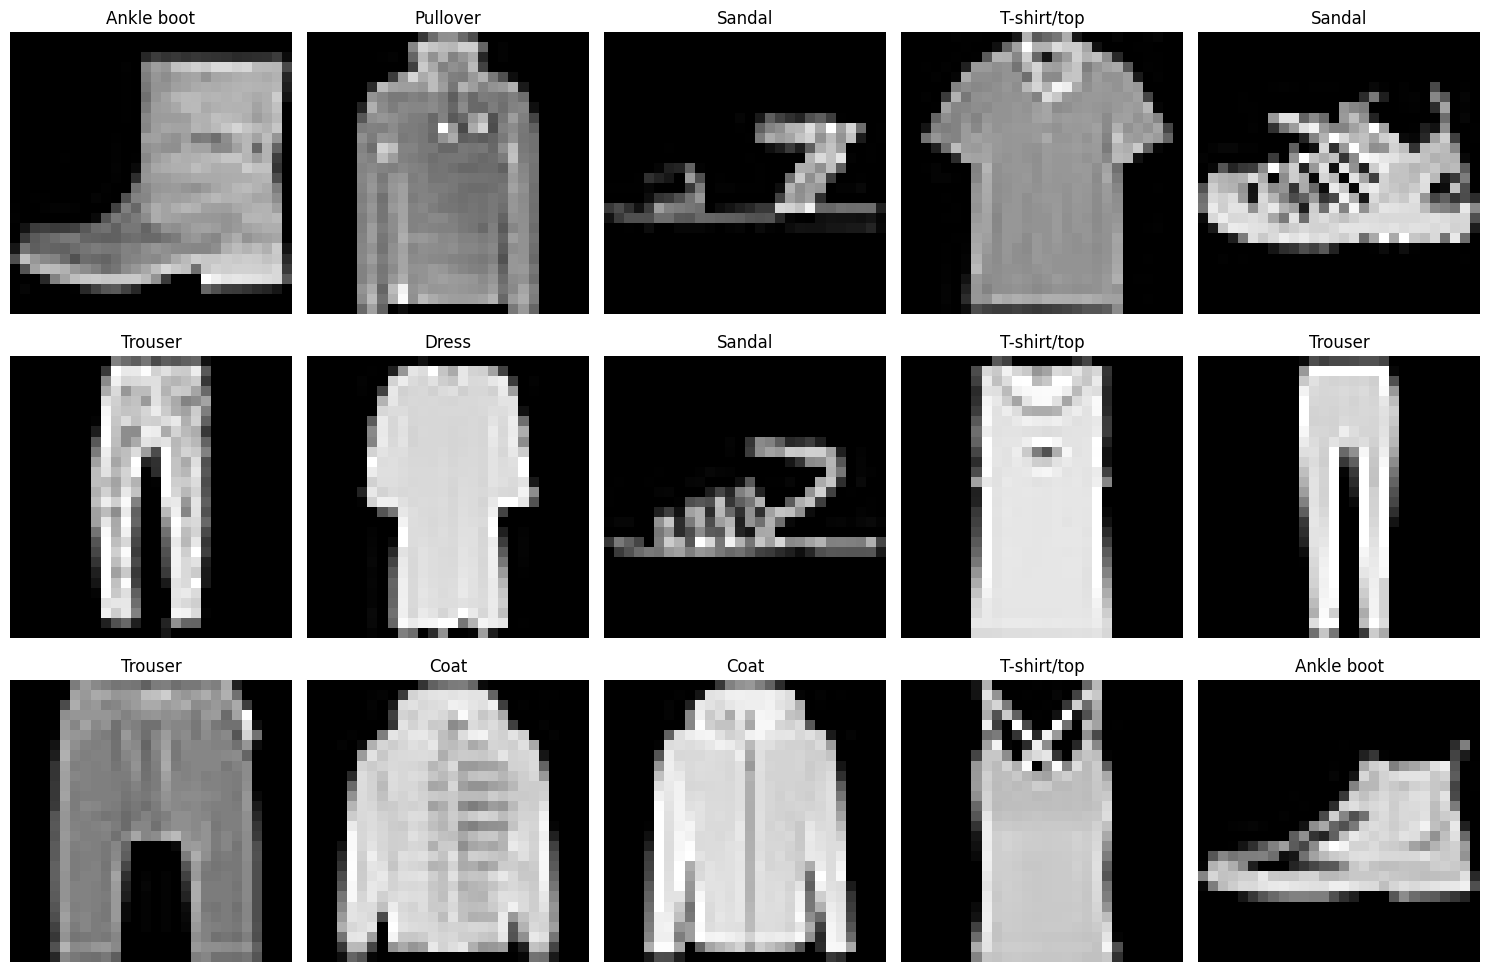

In [10]:
# 可视化训练集前 15 个样本，查看图片内容与对应标签
fig, axs = plt.subplots(3, 5, figsize=(15, 10))  # 创建 3×5 子图，画布大小 15×10 英寸
axs = axs.flatten()  # 将 2D 轴数组展平为 1D，方便索引

for i in range(15):
    img, label = train_dataset[i]  # img 形状: (1, 28, 28) 即 (C, H, W)，label 是 0-9 的整数
    img = img.squeeze().numpy()  # squeeze() 去掉通道维度 → (28, 28)，再转 numpy
    axs[i].imshow(img, cmap='gray')  # 以灰度图方式显示
    axs[i].set_title(class_names[label])  # 标题为对应的类别名称
    axs[i].axis('off')  # 隐藏坐标轴

plt.tight_layout()  # 自动调整子图间距，避免重叠
plt.show()

In [11]:
# 查看数据集基本信息
# train_dataset 总共 55000 个样本，每个样本是一个 (image_tensor, label) 元组
print("训练集类型:", type(train_dataset))
print("训练集样本总数:", len(train_dataset))  # 55000
print("单张图片的 shape (C, H, W):", train_dataset[0][0].shape)  # torch.Size([1, 28, 28])
print("第一张图片的标签编号:", train_dataset[0][1])  # 9 → Ankle boot

训练集类型: <class 'torch.utils.data.dataset.Subset'>
训练集样本总数: 55000
单张图片的 shape (C, H, W): torch.Size([1, 28, 28])
第一张图片的标签编号: 9


## 2.5 计算训练集的均值和标准差（用于后续标准化 Normalization）
标准化公式: x_norm = (x - mean) / std
计算前需先把所有样本堆叠成一个大 tensor，再按公式求均值与方差。
注意: 这里统计的是 train_dataset（已切分后的 55000 张），而非 full_train_dataset。
      若显存不足，可改用分批累加的方式计算，避免一次性加载全部图片。

In [12]:
# 将 train_dataset 中每张图片取出，组成列表；每个元素 shape 为 (1, 28, 28)
all_imgs = [train_dataset[i][0] for i in range(len(train_dataset))]

In [13]:
# torch.stack: 沿新维度(第0维)把列表中的张量堆叠起来
# 堆叠后 shape: (样本数 N, 1, 28, 28)
all_imgs = torch.stack(all_imgs)

## 📝 view() 与 -1 详解（PyTorch 最重要的张量操作之一）
view() 是改变张量形状的方法，不改变数据本身，只是"换一种方式看待"同一块内存。
-1 表示"你帮我自动算这个维度应该是多少"（只能有一个 -1）
举例说明：
  张量 shape = (2, 3, 4)，共 2×3×4 = 24 个元素
  .view(6, 4)      → (6, 4)   显式指定两维
  .view(-1, 4)     → (6, 4)   -1 自动推算为 24/4 = 6
  .view(2, -1)     → (2, 12)  -1 自动推算为 24/2 = 12
  .view(-1)        → (24,)    展平为一维
在模型中的典型用法：
  x.shape = (batch, 1, 28, 28)  图片：64张 × 1通道 × 28高 × 28宽
  x.view(x.size(0), -1)         x.size(0)=64, -1 自动推算为 1×28×28=784
  结果: (64, 784)               每张图片变成784维的向量

In [14]:
# view(-1): 将任意 shape 的张量展平为一维（共 N*1*28*28 个像素值）
# -1 表示该维度由系统根据元素总数自动推断
all_imgs_flat = all_imgs.view(-1)

In [15]:
# 计算所有像素值的均值: mean = (1/n) * Σ xi
mean = all_imgs_flat.mean().item()  # .item() 将标量张量转为 Python float

In [16]:
# 计算 (xi^2) 的均值: mean_of_squares = (1/n) * Σ xi^2
mean_of_squares = (all_imgs_flat ** 2).mean().item()

In [17]:
# 按方差公式计算: Var = E[X^2] - (E[X])^2 = mean(x^2) - mean(x)^2
# 该公式等价于 Σ(xi - mean)^2 / n，但计算更高效（无需二次遍历）
var = mean_of_squares - mean ** 2

In [18]:
print("Train dataset mean:", mean)  # 训练集像素均值（ToTensor 后约 0.2860）
print("Train dataset variance:", var)  # 训练集像素方差

Train dataset mean: 0.28556567430496216
Train dataset variance: 0.12441748148810561


In [19]:
# 标准差 = 方差的算术平方根
std = var ** 0.5
print("Train dataset std:", std)  # 训练集像素标准差（约 0.3530）

Train dataset std: 0.3527286230065624


### 用计算出的 mean/std 构建带标准化的 transform
transforms.Normalize(mean, std): 对每个通道逐元素做 (x - mean) / std
  - FashionMNIST 为单通道灰度图，故 mean/std 各传一个值，写成单元素元组 (mean,) (std,)
  - 归一化后像素分布变为均值 0、方差 1，输入尺度统一，有助于模型更快收敛
  - 顺序很重要: 必须先 ToTensor()（转为 0-1 浮点）再 Normalize()，不能反

In [20]:
transform = transforms.Compose([
    transforms.ToTensor(),  # 先把 PIL 图片转为 0.0-1.0 的张量
    transforms.Normalize((mean,), (std,))  # 再标准化: x_norm = (x - mean) / std
])

In [21]:
# 将新的 transform 重新挂载到已加载的数据集上
#   - 数据集在 __getitem__ 时才按"当前" self.transform 处理图片，
#     因此无需重新加载数据，直接重新赋值即可让后续迭代生效
#   - train_dataset / val_dataset 是 random_split 产生的 Subset，
#     其 __getitem__ 会委托给底层 full_train_dataset，所以只需修改
#     full_train_dataset.transform，训练集与验证集会同步生效
full_train_dataset.transform = transform  # 训练集与验证集（Subset 共享底层）同步生效
test_dataset.transform = transform  # 测试集也使用相同的标准化参数

In [22]:
print(f"已应用标准化: Normalize(mean={mean:.4f}, std={std:.4f})")

已应用标准化: Normalize(mean=0.2856, std=0.3527)


## 3. 模型定义（带调试打印版，用于理解数据流动）

In [23]:
class NeuralNetworkDebug(nn.Module):
    """
    三层全连接神经网络（带 shape 打印，便于理解各层数据流）
    输入: 28×28=784 像素 → 展平 → 300 → ReLU → 100 → ReLU → 10（10 分类 logits）
    """

    def __init__(self):
        super().__init__()
        # 全连接层1: 784 → 300
        self.fc1 = nn.Linear(28 * 28, 300)  # 输入 784 个神经元，输出 300 个
        # ReLU 激活函数: max(0, x)，引入非线性，缓解梯度消失
        self.relu1 = nn.ReLU()
        # 全连接层2: 300 → 100
        self.fc2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        # 全连接层3（输出层）: 100 → 10（对应 10 个类别）
        # 输出为 logits（未归一化），后续 CrossEntropyLoss 会自动做 softmax
        self.fc3 = nn.Linear(100, 10)

    def forward(self, x):
        """前向传播（包含调试打印）"""
        print("Before view:", x.shape)  # 例如 (1, 1, 28, 28)
        x = x.view(x.size(0), -1)  # 展平: (batch, 1, 28, 28) → (batch, 784)
        print("After view:", x.shape)  # (1, 784)
        x = self.fc1(x)  # 全连接层1: (batch, 784) → (batch, 300)
        print("After fc1:", x.shape)
        x = self.relu1(x)  # ReLU 激活: 负值置零，正值保持
        print("After relu1:", x.shape)
        x = self.fc2(x)  # 全连接层2: (batch, 300) → (batch, 100)
        print("After fc2:", x.shape)
        x = self.relu2(x)
        print("After relu2:", x.shape)
        x = self.fc3(x)  # 输出层: (batch, 100) → (batch, 10)
        print("After fc3:", x.shape)
        return x


# 用单张图片测试调试版模型的数据流
img, label = train_dataset[0]
img = img.unsqueeze(0)  # 在第0维增加 batch 维度: (1, 28, 28) → (1, 1, 28, 28)
model_debug = NeuralNetworkDebug()
output = model_debug(img)
print("Logits:", output)  # 10 个未归一化的类别分数
print("Predicted class:", torch.argmax(output, dim=1).item(), "True class:", label)
# argmax(output, dim=1): 沿第1维（类别维）取最大值的索引，即预测类别

Before view: torch.Size([1, 1, 28, 28])
After view: torch.Size([1, 784])
After fc1: torch.Size([1, 300])
After relu1: torch.Size([1, 300])
After fc2: torch.Size([1, 100])
After relu2: torch.Size([1, 100])
After fc3: torch.Size([1, 10])
Logits: tensor([[-0.0877,  0.0122,  0.1145,  0.0423,  0.0360,  0.1298, -0.1089, -0.1119,
         -0.1073,  0.0952]], grad_fn=<AddmmBackward0>)
Predicted class: 5 True class: 9


In [24]:
# 用真实 batch 数据测试（查看 batch 维度的数据流）
for images, labels in train_loader:
    print("images shape:", images.shape)  # (64, 1, 28, 28) = (batch_size, channel, height, width)
    print("labels shape:", labels.shape)  # (64,) = 64 个标签
    break

output = model_debug(images)
print("Logits shape:", output.shape)  # (64, 10) = 64 个样本，每个样本输出 10 个类别分数

images shape: torch.Size([64, 1, 28, 28])
labels shape: torch.Size([64])
Before view: torch.Size([64, 1, 28, 28])
After view: torch.Size([64, 784])
After fc1: torch.Size([64, 300])
After relu1: torch.Size([64, 300])
After fc2: torch.Size([64, 100])
After relu2: torch.Size([64, 100])
After fc3: torch.Size([64, 10])
Logits shape: torch.Size([64, 10])


## 4. 模型参数统计

In [25]:
print("\n========== 模型参数统计 ==========")
for name, param in model_debug.named_parameters():
    # param.numel(): 返回该参数张量的元素总数 (number of elements)
    print(f"Name: {name}, Shape: {param.shape}, Number of params: {param.numel()}")

# 计算总参数量: 遍历所有参数，累加元素个数
total_params = sum(p.numel() for p in model_debug.parameters())
print(f"Total number of parameters: {total_params}")  # 266,610


========== 模型参数统计 ==========
Name: fc1.weight, Shape: torch.Size([300, 784]), Number of params: 235200
Name: fc1.bias, Shape: torch.Size([300]), Number of params: 300
Name: fc2.weight, Shape: torch.Size([100, 300]), Number of params: 30000
Name: fc2.bias, Shape: torch.Size([100]), Number of params: 100
Name: fc3.weight, Shape: torch.Size([10, 100]), Number of params: 1000
Name: fc3.bias, Shape: torch.Size([10]), Number of params: 10
Total number of parameters: 266610


In [26]:
# 验证: fc1 权重参数量 = 300 × 784 = 235,200
print(f"验证 fc1.weight 参数量: 300 * 784 = {300 * 784}")

验证 fc1.weight 参数量: 300 * 784 = 235200


## 5. 正式模型定义（纯推理版，无调试打印）

In [27]:
class NeuralNetwork(nn.Module):
    """
    三层全连接神经网络（正式版，无调试打印）
    结构: Input(784) → FC(300) → ReLU → FC(100) → ReLU → FC(10)
    参数量计算:
      fc1: 784×300 + 300 = 235,500
      fc2: 300×100 + 100 = 30,100
      fc3: 100×10  + 10  = 1,010
      总计: 266,610
    """

    def __init__(self):
        super().__init__()
        # 第一层全连接: 将 784 维像素向量映射到 300 维特征空间
        self.fc1 = nn.Linear(28 * 28, 300)
        # ReLU 激活: f(x) = max(0, x)，保留正值，抑制负值，增加非线性表达能力
        self.relu1 = nn.ReLU()
        # 第二层全连接: 300 → 100，进一步提取高层特征
        self.fc2 = nn.Linear(300, 100)
        self.relu2 = nn.ReLU()
        # 输出层: 100 → 10，输出每个类别的原始分数（logits）
        # 注意: 此处没有加 Softmax，因为 CrossEntropyLoss 内部已包含 softmax + NLLLoss
        self.fc3 = nn.Linear(100, 10)

    def forward(self, x):
        """
        前向传播
        参数:
            x: 输入张量，形状 (batch_size, 1, 28, 28)
        返回:
            logits: 形状 (batch_size, 10)，每个类别的原始分数
        """
        # view: 将图片展平为向量，x.size(0) 是 batch_size，-1 表示自动计算剩余维度
        x = x.view(x.size(0), -1)  # (batch, 1, 28, 28) → (batch, 784)
        x = self.fc1(x)  # (batch, 784) → (batch, 300)
        x = self.relu1(x)  # ReLU 非线性激活
        x = self.fc2(x)  # (batch, 300) → (batch, 100)
        x = self.relu2(x)  # ReLU 非线性激活
        x = self.fc3(x)  # (batch, 100) → (batch, 10)
        return x


# 实例化正式模型
model = NeuralNetwork()

## 6. Trainer 训练器类
该类把"训练 + 验证 + 早停 + 保存最优模型 + TensorBoard 日志 + 绘图"封装在一起，
同时支持分类任务（带准确率）与回归任务（仅损失）。

In [28]:
class Trainer:
    """通用训练器：封装训练循环、评估、早停、模型保存与可视化。"""

    def __init__(
            self,
            model,  # 待训练的 PyTorch 模型
            trainloader,  # 训练集 DataLoader
            valloader,  # 验证集 DataLoader
            criterion,  # 损失函数
            optimizer,  # 优化器
            device='cuda',  # 训练设备，默认 GPU
            epochs=10,  # 训练总轮数，默认 10
            early_stopping=True,  # 是否启用早停机制
            patience=5,  # 早停容忍度：连续多少轮未提升则停止
            save_path="best_model.pth",  # 最优模型权重保存路径
            early_stop_mode="loss",  # 早停依据："loss"(损失越小越好) 或 "acc"(准确率)
            maximize_acc=True,  # acc 模式下：True=越大越好，False=越小越好
            use_tensorboard=True,  # 是否启用 TensorBoard 日志记录
            log_dir='tensorboard_logs'  # TensorBoard 日志目录
    ):
        self.model = model  # 保存模型实例
        self.trainloader = trainloader  # 保存训练集加载器
        self.valloader = valloader  # 保存验证集加载器
        self.criterion = criterion  # 保存损失函数
        self.optimizer = optimizer  # 保存优化器
        self.device = device  # 保存训练设备
        self.epochs = epochs  # 保存训练轮数
        self.train_losses = []  # 记录每轮训练集损失（用于绘图）
        self.val_losses = []  # 记录每轮验证集损失
        self.train_accuracies = []  # 记录每轮训练集准确率
        self.val_accuracies = []  # 记录每轮验证集准确率

        self.early_stopping = early_stopping  # 是否开启早停
        self.patience = patience  # 早停容忍度
        self.save_path = save_path  # 最优模型保存路径
        self.early_stop_mode = early_stop_mode  # 早停模式：'loss' 或 'acc'
        self.maximize_acc = maximize_acc  # acc 越大越好还是越小越好（一般 True）

        # 初始化早停相关变量
        self.best_metric = None  # 历史最优度量值（损失或准确率）
        self.early_stop_counter = 0  # 连续未提升的轮数计数器
        self.best_epoch = 0  # 取得最优度量值时的轮次

        # TensorBoard 相关
        self.use_tensorboard = use_tensorboard  # 是否使用 TensorBoard
        self._writer = None  # 写入器句柄，初始为 None
        if self.use_tensorboard:  # 若启用 TensorBoard
            if not os.path.exists(log_dir):  # 日志目录不存在则创建
                os.makedirs(log_dir)  # 递归创建日志目录
            self._writer = SummaryWriter(log_dir)  # 创建日志写入器

    def evaluating(self, dataloader):
        """分类任务评估：返回 (平均损失, 准确率)。"""
        self.model.eval()  # 切换到评估模式（关闭 Dropout/冻结 BN）
        correct = 0  # 累计预测正确数
        total = 0  # 累计样本总数
        running_loss = 0.0  # 累计损失
        with torch.no_grad():  # 关闭梯度计算，节省显存与算力
            for images, labels in dataloader:  # 遍历每个 batch
                images = images.to(self.device)  # 图片移至设备
                labels = labels.to(self.device)  # 标签移至设备
                outputs = self.model(images)  # 前向传播得到 logits
                loss = self.criterion(outputs, labels)  # 计算该 batch 损失
                running_loss += loss.item()  # 累加损失（转 Python float）
                predicted = torch.argmax(outputs, dim=1)  # 取得分最高的类别索引
                total += labels.size(0)  # 累加样本数
                correct += (predicted == labels).sum().item()  # 累加预测正确数
        acc = 100 * correct / total if total > 0 else 0  # 计算准确率（百分比）
        avg_loss = running_loss / len(dataloader)  # 计算平均损失
        return avg_loss, acc  # 返回平均损失和准确率

    def regression_evaluating(self, dataloader):
        """回归任务评估：仅返回平均损失（无准确率概念）。"""
        self.model.eval()  # 切换到评估模式
        running_loss = 0.0  # 累计损失
        with torch.no_grad():  # 关闭梯度计算
            for data, target in dataloader:  # 遍历每个 batch
                data = data.to(self.device)  # 输入移至设备
                target = target.to(self.device)  # 目标值移至设备
                output = self.model(data)  # 前向传播得到预测值
                loss = self.criterion(output, target)  # 计算损失
                running_loss += loss.item()  # 累加损失
        avg_loss = running_loss / len(dataloader)  # 计算平均损失
        return avg_loss  # 返回平均损失

    def regression_train(self):
        """回归任务训练循环：仅记录损失，不计算准确率。"""
        self.model.to(self.device)  # 模型移至设备
        for epoch in range(self.epochs):  # 逐轮训练
            self.model.train()  # 切换到训练模式
            running_loss = 0.0  # 本轮损失累加器清零
            for batch_idx, (inputs, targets) in enumerate(self.trainloader):  # 遍历 batch
                inputs = inputs.to(self.device)  # 输入移至设备
                targets = targets.to(self.device)  # 目标移至设备
                self.optimizer.zero_grad()  # 梯度清零
                outputs = self.model(inputs)  # 前向传播
                loss = self.criterion(outputs, targets)  # 计算损失
                loss.backward()  # 反向传播求梯度
                self.optimizer.step()  # 更新参数
                running_loss += loss.item()  # 累加损失
                if (batch_idx + 1) % 100 == 0:  # 每 100 步打印一次
                    print(
                        f"[Regression] Epoch [{epoch + 1}/{self.epochs}], Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}")
            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失
            train_loss = self.regression_evaluating(self.trainloader)  # 评估训练集损失
            val_loss = self.regression_evaluating(self.valloader)  # 评估验证集损失
            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            print(
                f"[Regression] Epoch [{epoch + 1}/{self.epochs}], Loss: {avg_train_loss:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
            # ====== TensorBoard 日志记录 ======
            if self.use_tensorboard and self._writer is not None:  # 若启用写入器
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 记录训练损失
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 记录验证损失
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历每个参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ====== 早停与模型保存 ======
            metric = val_loss  # 回归任务只用验证损失作为度量
            if self.early_stopping:  # 若启用早停
                if self.best_metric is None or metric < self.best_metric:  # 首次或损失下降
                    self.best_metric = metric  # 更新最优损失
                    self.early_stop_counter = 0  # 重置计数器
                    self.best_epoch = epoch + 1  # 记录最优轮次
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优权重
                    print(f"[Info][Regression] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 损失未下降
                    self.early_stop_counter += 1  # 计数器加一
                    print(f"[Info][Regression] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 超过容忍度则停止
                        print(
                            f"[Regression] Early stopping triggered at epoch {epoch + 1}. Best epoch: {self.best_epoch}, Best Loss: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 若已保存过最优权重
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
                        if self.use_tensorboard and self._writer is not None:  # 关闭写入器
                            self._writer.close()
                        return  # 结束训练

        # 全部轮次跑完且未触发早停：加载最优权重
        if self.early_stopping and self.best_metric is not None:  # 曾保存过最优
            print(f"[Regression] Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 若存在权重文件
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:  # 训练结束关闭写入器
            self._writer.close()

    def _is_improvement(self, metric):
        """根据早停模式判断当前度量是否优于历史最优。"""
        if self.best_metric is None:  # 尚无历史最优，视为提升
            return True
        if self.early_stop_mode == "loss":  # loss 模式：越小越好
            return metric < self.best_metric
        elif self.early_stop_mode == "acc":  # acc 模式
            if self.maximize_acc:  # 越大越好
                return metric > self.best_metric
            else:  # 越小越好
                return metric < self.best_metric
        else:  # 未知模式报错
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def _get_val_metric(self, val_loss, val_acc):
        """根据早停模式返回用于比较的度量值。"""
        if self.early_stop_mode == "loss":  # loss 模式返回损失
            return val_loss
        elif self.early_stop_mode == "acc":  # acc 模式返回准确率
            return val_acc
        else:  # 未知模式报错
            raise ValueError("Unknown early_stop_mode: {}".format(self.early_stop_mode))

    def train(self):
        """分类任务训练主循环（带早停、保存与 TensorBoard）。"""
        self.model.to(self.device)  # 模型移至设备
        for epoch in range(self.epochs):  # 逐轮训练
            self.model.train()  # 切换到训练模式
            running_loss = 0.0  # 本轮损失累加器清零
            for batch_idx, (images, labels) in enumerate(self.trainloader):  # 遍历 batch
                images = images.to(self.device)  # 图片移至设备
                labels = labels.to(self.device)  # 标签移至设备
                self.optimizer.zero_grad()  # 梯度清零
                outputs = self.model(images)  # 前向传播
                loss = self.criterion(outputs, labels)  # 计算损失
                loss.backward()  # 反向传播
                self.optimizer.step()  # 更新参数
                running_loss += loss.item()  # 累加损失
                if (batch_idx + 1) % 100 == 0:  # 每 100 步打印一次
                    print(
                        f'Epoch [{epoch + 1}/{self.epochs}], Step [{batch_idx + 1}/{len(self.trainloader)}], Loss: {loss.item():.4f}')

            avg_train_loss = running_loss / len(self.trainloader)  # 本轮平均训练损失
            train_loss, train_acc = self.evaluating(self.trainloader)  # 评估训练集
            val_loss, val_acc = self.evaluating(self.valloader)  # 评估验证集

            self.train_losses.append(train_loss)  # 记录训练损失
            self.val_losses.append(val_loss)  # 记录验证损失
            self.train_accuracies.append(train_acc)  # 记录训练准确率
            self.val_accuracies.append(val_acc)  # 记录验证准确率
            print(
                f'Epoch [{epoch + 1}/{self.epochs}], Loss: {avg_train_loss:.4f}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}, Train Acc: {train_acc:.2f}%, Val Acc: {val_acc:.2f}%')  # 打印本轮汇总

            # ====== TensorBoard 日志记录 ======
            if self.use_tensorboard and self._writer is not None:  # 若启用写入器
                self._writer.add_scalar('Train/Loss', train_loss, epoch + 1)  # 记录训练损失
                self._writer.add_scalar('Train/Accuracy', train_acc, epoch + 1)  # 记录训练准确率
                self._writer.add_scalar('Val/Loss', val_loss, epoch + 1)  # 记录验证损失
                self._writer.add_scalar('Val/Accuracy', val_acc, epoch + 1)  # 记录验证准确率
                for i, param_group in enumerate(self.optimizer.param_groups):  # 遍历参数组
                    self._writer.add_scalar(f'LR/group_{i}', param_group['lr'], epoch + 1)  # 记录学习率

            # ====== 早停与模型保存 ======
            metric = self._get_val_metric(val_loss, val_acc)  # 取验证集损失或准确率作为度量
            if self.early_stopping:  # 若启用早停
                if self._is_improvement(metric):  # 判断是否为最优
                    self.best_metric = metric  # 更新最优度量
                    self.early_stop_counter = 0  # 重置计数器
                    self.best_epoch = epoch + 1  # 记录最优轮次
                    torch.save(self.model.state_dict(), self.save_path)  # 保存最优权重
                    print(f"[Info] Model improved at epoch {epoch + 1}, saving to {self.save_path}")
                else:  # 未提升
                    self.early_stop_counter += 1  # 计数器加一
                    print(f"[Info] Early stop counter: {self.early_stop_counter}/{self.patience}")
                    if self.early_stop_counter >= self.patience:  # 超过容忍度则停止
                        print(
                            f"Early stopping triggered at epoch {epoch + 1}. Best epoch: {self.best_epoch}, Best metric: {self.best_metric:.4f}")
                        if os.path.isfile(self.save_path):  # 若存在权重文件
                            self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
                        if self.use_tensorboard and self._writer is not None:  # 关闭写入器
                            self._writer.close()
                        return  # 结束训练

        # 全部轮次跑完且未触发早停：加载最优权重
        if self.early_stopping and self.best_metric is not None:  # 曾保存过最优
            print(f"Training finished. Loading best model from {self.save_path}")
            if os.path.isfile(self.save_path):  # 若存在权重文件
                self.model.load_state_dict(torch.load(self.save_path, map_location=self.device))  # 恢复最优权重
        if self.use_tensorboard and self._writer is not None:  # 关闭写入器
            self._writer.close()

    def plot(self, acc=True):
        """可视化训练过程；acc=True 画准确率+损失，False 仅画损失（回归）。"""
        epochs_range = range(1, len(self.train_losses) + 1)  # 横坐标：epoch 序号
        if acc:  # 分类任务：损失 + 准确率双图
            plt.figure(figsize=(14, 5))  # 创建画布
            # 子图1：损失曲线
            plt.subplot(1, 2, 1)  # 1行2列第1个
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            # 子图2：准确率曲线
            plt.subplot(1, 2, 2)  # 1行2列第2个
            plt.plot(epochs_range, self.train_accuracies, label='Train Accuracy')  # 训练准确率
            plt.plot(epochs_range, self.val_accuracies, label='Validation Accuracy')  # 验证准确率
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Accuracy (%)')  # 纵轴标签
            plt.title('Training and Validation Accuracy')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            plt.tight_layout()  # 自动调整子图间距
            plt.show()  # 显示图像
        else:  # 回归任务：仅损失曲线
            plt.figure(figsize=(7, 5))  # 创建画布
            plt.plot(epochs_range, self.train_losses, label='Train Loss')  # 训练损失
            plt.plot(epochs_range, self.val_losses, label='Validation Loss')  # 验证损失
            plt.xlabel('Epoch')  # 横轴标签
            plt.ylabel('Loss')  # 纵轴标签
            plt.title('Training and Validation Loss')  # 标题
            plt.legend()  # 显示图例
            plt.grid(True)  # 显示网格
            plt.tight_layout()  # 自动调整子图间距
            plt.show()  # 显示图像

## 7. 训练准备

In [29]:
# 判断并选择运行设备
# cuda: GPU（NVIDIA 显卡），训练速度远超 CPU
# cpu:  中央处理器，无 GPU 时回退
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n使用设备: {device}")


使用设备: cuda


In [30]:
# 损失函数: 交叉熵损失 CrossEntropyLoss
# 内部自动完成: softmax + 负对数似然损失(NLLLoss)
# 公式: Loss = -log(softmax(logits)[true_class])
# 适用于多分类任务，输入为 logits（原始分数），不需要提前做 softmax
criterion = nn.CrossEntropyLoss()

In [31]:
# 优化器: 随机梯度下降 SGD + 动量 Momentum
# lr=0.01: 学习率，控制参数更新的步长
#   - 太大: 可能无法收敛，损失震荡
#   - 太小: 收敛缓慢，训练时间长
# momentum=0.9: 动量系数，累积历史梯度方向，加速收敛并减少震荡
#   - 取值通常在 [0, 1)，0.9 是常用默认值
optimizer = optim.SGD(
    model.parameters(),  # 需要优化的参数
    lr=0.01,  # 学习率 (learning rate)
    momentum=0.9  # 动量 (momentum)
)

## 8. 评估函数

In [32]:
def evaluating(model, dataloader, device=device):
    """
    在给定数据加载器上计算模型的分类准确率

    参数:
        model:      PyTorch 模型
        dataloader: 数据加载器 (验证集或测试集)
        device:     运行设备 ("cuda" 或 "cpu")

    返回:
        acc: 准确率 (%)，float
    """
    model.eval()  # 切换到评估模式: 关闭 Dropout、冻结 BatchNorm 统计量等
    correct = 0  # 累计预测正确的样本数
    total = 0  # 累计总样本数

    # torch.no_grad(): 禁用自动求导
    # 评估阶段不需要计算梯度，可以大幅节省显存和计算量
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)  # 将数据移至 GPU/CPU
            labels = labels.to(device)
            outputs = model(images)  # 前向传播，获得 logits，形状 (batch, 10)

            # argmax(outputs, dim=1): 在类别维度上取最大值的索引
            # dim=1 表示沿第 1 维（10 个类别的分数）找最大值位置
            predicted = torch.argmax(outputs, dim=1)

            total += labels.size(0)  # 累加当前 batch 的样本数
            correct += (predicted == labels).sum().item()  # 累加预测正确的数量

    acc = 100 * correct / total  # 转换为百分比

    return acc

## 9. 训练函数

In [33]:
def train(model, trainloader, valloader, criterion, optimizer, epochs=10, device=device):
    """
    训练模型的主循环

    参数:
        model:       PyTorch 模型
        trainloader: 训练集数据加载器
        valloader:   验证集数据加载器
        criterion:   损失函数 (CrossEntropyLoss)
        optimizer:   优化器 (SGD)
        epochs:      训练轮数，默认 10
        device:      运行设备 ("cuda" 或 "cpu")

    训练流程（每个 epoch）:
        1. 遍历所有 batch
        2. 前向传播 → 计算损失
        3. 反向传播 → 梯度清零 → 参数更新
        4. 定期打印 batch loss
        5. epoch 结束后计算训练集和验证集准确率
    """
    model.to(device)  # 将模型参数迁移到目标设备 (GPU/CPU)

    for epoch in range(epochs):
        model.train()  # 切换到训练模式: 启用 Dropout、BatchNorm 等
        running_loss = 0.0  # 累积当前 epoch 的所有 batch 损失

        # enumerate 返回 (batch索引, (图片batch, 标签batch))
        for batch_idx, (images, labels) in enumerate(trainloader):
            images = images.to(device)  # 将图片数据移动到指定设备
            labels = labels.to(device)  # 将标签数据移动到指定设备

            # ---- 核心训练五步 ----
            optimizer.zero_grad()  # 1. 清空上一轮的梯度（PyTorch 默认累加梯度）
            outputs = model(images)  # 2. 前向传播，得到预测 logits
            loss = criterion(outputs, labels)  # 3. 计算损失
            loss.backward()  # 4. 反向传播，计算梯度
            optimizer.step()  # 5. 更新参数: w = w - lr * grad

            running_loss += loss.item()  # loss.item() 将标量张量转为 Python float

            # 每 100 个 batch 打印一次当前 batch 的损失
            if (batch_idx + 1) % 100 == 0:
                print(f'Epoch [{epoch + 1}/{epochs}], '
                      f'Step [{batch_idx + 1}/{len(trainloader)}], '
                      f'Loss: {loss.item():.4f}')

        # 每个 epoch 结束后计算并打印平均损失、训练集准确率和验证集准确率
        avg_loss = running_loss / len(trainloader)  # 平均损失
        train_acc = evaluating(model, trainloader, device)  # 训练集准确率
        val_acc = evaluating(model, valloader, device)  # 验证集准确率
        print(f'Epoch [{epoch + 1}/{epochs}], '
              f'Loss: {avg_loss:.4f}, '
              f'Train Acc: {train_acc:.2f}%, '
              f'Val Acc: {val_acc:.2f}%')

## 10. 开始训练

In [34]:
num_epochs = 10  # 训练轮数: 可根据需要调整，增大有利于充分训练但可能过拟合
print(f"\n========== 开始训练 (epochs={num_epochs}) ==========")


========== 开始训练 (epochs=10) ==========


In [35]:
# 方式一：使用上方独立的 train() 函数训练（基础版，无早停/保存）
train(model, train_loader, val_loader, criterion, optimizer, epochs=num_epochs, device=device)

Epoch [1/10], Step [100/860], Loss: 0.5571
Epoch [1/10], Step [200/860], Loss: 0.3525
Epoch [1/10], Step [300/860], Loss: 0.4623
Epoch [1/10], Step [400/860], Loss: 0.4423
Epoch [1/10], Step [500/860], Loss: 0.2667
Epoch [1/10], Step [600/860], Loss: 0.5061
Epoch [1/10], Step [700/860], Loss: 0.4957
Epoch [1/10], Step [800/860], Loss: 0.4709
Epoch [1/10], Loss: 0.5350, Train Acc: 86.58%, Val Acc: 85.40%
Epoch [2/10], Step [100/860], Loss: 0.4256
Epoch [2/10], Step [200/860], Loss: 0.3200
Epoch [2/10], Step [300/860], Loss: 0.4210
Epoch [2/10], Step [400/860], Loss: 0.2196
Epoch [2/10], Step [500/860], Loss: 0.3339
Epoch [2/10], Step [600/860], Loss: 0.3344
Epoch [2/10], Step [700/860], Loss: 0.4449
Epoch [2/10], Step [800/860], Loss: 0.4134
Epoch [2/10], Loss: 0.3638, Train Acc: 87.65%, Val Acc: 85.92%
Epoch [3/10], Step [100/860], Loss: 0.3214
Epoch [3/10], Step [200/860], Loss: 0.2531
Epoch [3/10], Step [300/860], Loss: 0.2507
Epoch [3/10], Step [400/860], Loss: 0.4311
Epoch [3/10], 

Epoch [1/10], Step [100/860], Loss: 0.2414
Epoch [1/10], Step [200/860], Loss: 0.1552
Epoch [1/10], Step [300/860], Loss: 0.1661
Epoch [1/10], Step [400/860], Loss: 0.2460
Epoch [1/10], Step [500/860], Loss: 0.1279
Epoch [1/10], Step [600/860], Loss: 0.2473
Epoch [1/10], Step [700/860], Loss: 0.2224
Epoch [1/10], Step [800/860], Loss: 0.3508
Epoch [1/10], Loss: 0.1963, Train Loss: 0.1788, Val Loss: 0.3262, Train Acc: 93.16%, Val Acc: 88.82%
[Info] Model improved at epoch 1, saving to best_model.pth
Epoch [2/10], Step [100/860], Loss: 0.0954
Epoch [2/10], Step [200/860], Loss: 0.2050
Epoch [2/10], Step [300/860], Loss: 0.1313
Epoch [2/10], Step [400/860], Loss: 0.1810
Epoch [2/10], Step [500/860], Loss: 0.1358
Epoch [2/10], Step [600/860], Loss: 0.1568
Epoch [2/10], Step [700/860], Loss: 0.1728
Epoch [2/10], Step [800/860], Loss: 0.2507
Epoch [2/10], Loss: 0.1906, Train Loss: 0.1859, Val Loss: 0.3365, Train Acc: 92.98%, Val Acc: 88.18%
[Info] Early stop counter: 1/5
Epoch [3/10], Step [

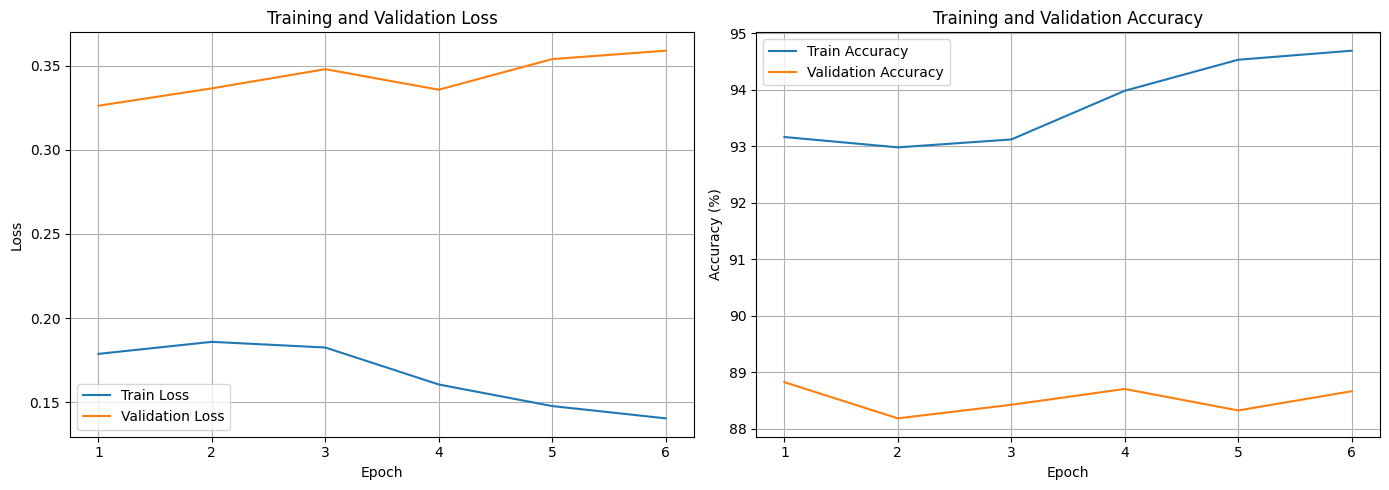

In [36]:
# 方式二：使用 Trainer 训练器训练（推荐，含早停/最优保存/TensorBoard/绘图）
trainer = Trainer(  # 实例化训练器
    model=model,  # 待训练模型
    trainloader=train_loader,  # 训练集加载器
    valloader=val_loader,  # 验证集加载器
    criterion=criterion,  # 损失函数
    optimizer=optimizer,  # 优化器
    device=device,  # 训练设备
    epochs=num_epochs,  # 训练轮数
    early_stopping=True,  # 启用早停
    patience=5,  # 连续 5 轮无提升则停止
    save_path="best_model.pth",  # 最优权重保存路径
    early_stop_mode="loss",  # 以验证损失作为早停依据
    use_tensorboard=True,  # 启用 TensorBoard
    log_dir='tensorboard_logs'  # 日志目录
)
trainer.train()  # 开始训练（内部自动完成早停与权重保存）
trainer.plot(acc=True)  # 绘制训练/验证的损失与准确率曲线

In [37]:
# 验证: 训练集总 batch 数 = 55000 / 64 ≈ 859.375 → 860 (向上取整)
print(f"\n训练集 batch 总数 (验证): {55000 / 64:.3f}")


训练集 batch 总数 (验证): 859.375
